<a href="https://colab.research.google.com/github/phaniraghava1234/physics_informed_neural_networks/blob/main/1d_Euler_Shock_Tube_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import os
project_path = "/content/drive/MyDrive/ColabProjects/physics_informed_neural_networks"

os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/ColabProjects/physics_informed_neural_networks


In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. Device Configuration
# ==========================================
# explicitly use the T4 GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


In [10]:
# ==========================================
# 1. Neural Network Architecture
# ==========================================
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.activation = nn.Tanh()
        self.loss_function = nn.MSELoss(reduction='mean')

        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])

        for i in range(len(layers)-1):
            nn.init.xavier_normal_(self.linears[i].weight)
            nn.init.zeros_(self.linears[i].bias)

    def forward(self, x, t):
        a = torch.cat([x, t], dim=1)
        for i in range(len(self.linears) - 1):
            a = self.activation(self.linears[i](a))
        out = self.linears[-1](a)

        rho = nn.Softplus()(out[:, 0:1])
        u = out[:, 1:2]
        p = nn.Softplus()(out[:, 2:3])

        return rho, u, p

In [11]:
# ==========================================
# 2. Physics-Informed Loss Components (Euler Equations)
# ==========================================
def compute_physics_loss(model, x_f, t_f, gamma=1.4, nu=0.01):
    x_f.requires_grad_(True)
    t_f.requires_grad_(True)

    rho, u, p = model(x_f, t_f)

    rho_t = torch.autograd.grad(rho, t_f, grad_outputs=torch.ones_like(rho), create_graph=True)[0]
    rho_x = torch.autograd.grad(rho, x_f, grad_outputs=torch.ones_like(rho), create_graph=True)[0]

    u_t = torch.autograd.grad(u, t_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    p_t = torch.autograd.grad(p, t_f, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x_f, grad_outputs=torch.ones_like(p), create_graph=True)[0]

    rho_xx = torch.autograd.grad(rho_x, x_f, grad_outputs=torch.ones_like(rho_x), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    p_xx = torch.autograd.grad(p_x, x_f, grad_outputs=torch.ones_like(p_x), create_graph=True)[0]

    f_mass = rho_t + u * rho_x + rho * u_x - nu * rho_xx
    f_momentum = u_t + u * u_x + (1/rho) * p_x - nu * u_xx
    f_energy = p_t + u * p_x + gamma * p * u_x - nu * p_xx

    loss_f = nn.MSELoss()(f_mass, torch.zeros_like(f_mass)) + \
             nn.MSELoss()(f_momentum, torch.zeros_like(f_momentum)) + \
             nn.MSELoss()(f_energy, torch.zeros_like(f_energy))

    return loss_f


In [12]:
# ==========================================
# 3. Exact Analytical Solver (Sod Shock Tube)
# ==========================================
def exact_sod_solution(x_arr, t, gamma=1.4):
    rho_L, u_L, p_L = 1.0, 0.0, 1.0
    rho_R, u_R, p_R = 0.125, 0.0, 0.1
    x0 = 0.5

    p_3, u_3, rho_3, rho_4 = 0.30313, 0.92745, 0.42632, 0.26557
    c_L = np.sqrt(gamma * p_L / rho_L)
    c_3 = np.sqrt(gamma * p_3 / rho_3)
    shock_speed = 1.7522

    x_head = x0 - c_L * t
    x_tail = x0 + (u_3 - c_3) * t
    x_contact = x0 + u_3 * t
    x_shock = x0 + shock_speed * t

    rho_exact, u_exact, p_exact = np.zeros_like(x_arr), np.zeros_like(x_arr), np.zeros_like(x_arr)

    for i, x in enumerate(x_arr):
        if x < x_head:
            rho_exact[i], u_exact[i], p_exact[i] = rho_L, u_L, p_L
        elif x_head <= x < x_tail:
            u_exact[i] = 2 / (gamma + 1) * (c_L + (x - x0) / t)
            c_fan = c_L - (gamma - 1) / 2 * u_exact[i]
            p_exact[i] = p_L * (c_fan / c_L)**(2 * gamma / (gamma - 1))
            rho_exact[i] = rho_L * (c_fan / c_L)**(2 / (gamma - 1))
        elif x_tail <= x < x_contact:
            rho_exact[i], u_exact[i], p_exact[i] = rho_3, u_3, p_3
        elif x_contact <= x < x_shock:
            rho_exact[i], u_exact[i], p_exact[i] = rho_4, u_3, p_3
        else:
            rho_exact[i], u_exact[i], p_exact[i] = rho_R, u_R, p_R

    return rho_exact, u_exact, p_exact

In [13]:
# ==========================================
# 4. Training Data & Setup
# ==========================================
N_u = 400
N_f = 10000
gamma = 1.4

x_lower, x_upper = 0.0, 1.0
t_lower, t_upper = 0.0, 0.2

x_ic = np.random.uniform(x_lower, x_upper, (N_u, 1))
t_ic = np.zeros((N_u, 1))
k = 50
rho_ic = 0.125 + (1.0 - 0.125) / (1 + np.exp(k * (x_ic - 0.5)))
p_ic = 0.1 + (1.0 - 0.1) / (1 + np.exp(k * (x_ic - 0.5)))
u_ic = np.zeros((N_u, 1))

x_bc_left = np.full((N_u, 1), x_lower)
x_bc_right = np.full((N_u, 1), x_upper)
t_bc = np.random.uniform(t_lower, t_upper, (N_u, 1))

rho_bc_left, p_bc_left, u_bc_left = np.full((N_u, 1), 1.0), np.full((N_u, 1), 1.0), np.zeros((N_u, 1))
rho_bc_right, p_bc_right, u_bc_right = np.full((N_u, 1), 0.125), np.full((N_u, 1), 0.1), np.zeros((N_u, 1))

x_data = np.vstack([x_ic, x_bc_left, x_bc_right])
t_data = np.vstack([t_ic, t_bc, t_bc])
rho_data = np.vstack([rho_ic, rho_bc_left, rho_bc_right])
u_data = np.vstack([u_ic, u_bc_left, u_bc_right])
p_data = np.vstack([p_ic, p_bc_left, p_bc_right])

# Move data to GPU
x_data_pt = torch.tensor(x_data, dtype=torch.float32, device=device)
t_data_pt = torch.tensor(t_data, dtype=torch.float32, device=device)
rho_data_pt = torch.tensor(rho_data, dtype=torch.float32, device=device)
u_data_pt = torch.tensor(u_data, dtype=torch.float32, device=device)
p_data_pt = torch.tensor(p_data, dtype=torch.float32, device=device)

# Move collocation points to GPU
x_f_pt = torch.tensor(np.random.uniform(x_lower, x_upper, (N_f, 1)), dtype=torch.float32, device=device)
t_f_pt = torch.tensor(np.random.uniform(t_lower, t_upper, (N_f, 1)), dtype=torch.float32, device=device)


In [14]:
# ==========================================
# 5. Training Loop
# ==========================================
layers = [2, 40, 40, 40, 40, 40, 40, 40, 40, 3]
model = PINN(layers).to(device) # Move model to GPU

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 8000

print("Starting Euler PINN Training on GPU...")
for epoch in range(epochs):
    optimizer.zero_grad()

    rho_pred, u_pred, p_pred = model(x_data_pt, t_data_pt)
    loss_data = model.loss_function(rho_pred, rho_data_pt) + \
                model.loss_function(u_pred, u_data_pt) + \
                model.loss_function(p_pred, p_data_pt)

    loss_physics = compute_physics_loss(model, x_f_pt, t_f_pt, gamma, nu=0.01)

    loss = loss_data + loss_physics
    loss.backward()
    optimizer.step()

    if epoch == 5000:
        for g in optimizer.param_groups:
            g['lr'] = 1e-4

    if epoch % 1000 == 0:
        print(f'Epoch: {epoch:05d}, Total Loss: {loss.item():.6f}')

print("Training Complete!")

Starting Euler PINN Training on GPU...
Epoch: 00000, Total Loss: 0.397516
Epoch: 01000, Total Loss: 0.009576
Epoch: 02000, Total Loss: 0.003743
Epoch: 03000, Total Loss: 0.011910
Epoch: 04000, Total Loss: 0.001303
Epoch: 05000, Total Loss: 0.002960
Epoch: 06000, Total Loss: 0.000749
Epoch: 07000, Total Loss: 0.000683
Training Complete!


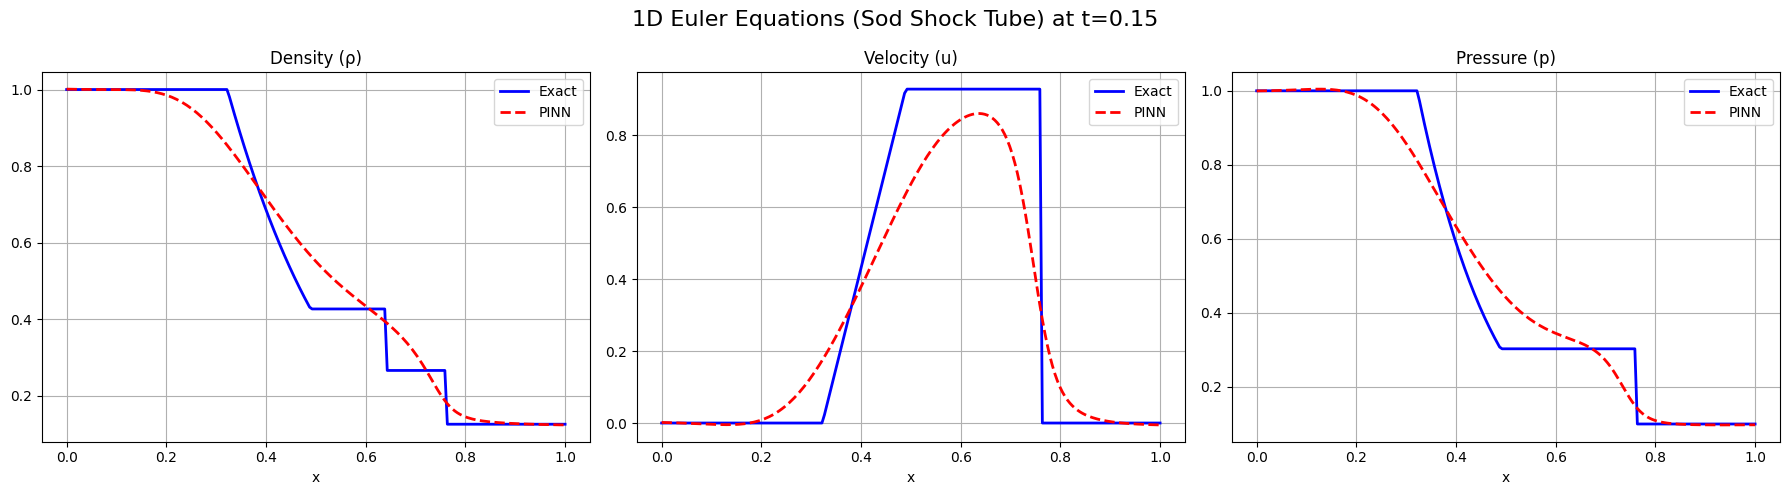

In [19]:
# ==========================================
# 6. Evaluation & Plotting
# ==========================================
t_val = 0.15
x_test = np.linspace(0, 1, 200)

# Move test data to GPU for inference
x_test_pt = torch.tensor(x_test[:, None], dtype=torch.float32, device=device)
t_test_pt = torch.tensor(np.full((200, 1), t_val), dtype=torch.float32, device=device)

with torch.no_grad():
    rho_pred, u_pred, p_pred = model(x_test_pt, t_test_pt)
    # Bring predictions back to CPU for matplotlib
    rho_pred = rho_pred.cpu().numpy().flatten()
    u_pred = u_pred.cpu().numpy().flatten()
    p_pred = p_pred.cpu().numpy().flatten()

rho_exact, u_exact, p_exact = exact_sod_solution(x_test, t_val, gamma)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'1D Euler Equations (Sod Shock Tube) at t={t_val}', fontsize=16)

axs[0].plot(x_test, rho_exact, 'b-', label='Exact', linewidth=2)
axs[0].plot(x_test, rho_pred, 'r--', label='PINN', linewidth=2)
axs[0].set_title('Density (ρ)')
axs[0].set_xlabel('x')
axs[0].grid(True); axs[0].legend()

axs[1].plot(x_test, u_exact, 'b-', label='Exact', linewidth=2)
axs[1].plot(x_test, u_pred, 'r--', label='PINN', linewidth=2)
axs[1].set_title('Velocity (u)')
axs[1].set_xlabel('x')
axs[1].grid(True); axs[1].legend()

axs[2].plot(x_test, p_exact, 'b-', label='Exact', linewidth=2)
axs[2].plot(x_test, p_pred, 'r--', label='PINN', linewidth=2)
axs[2].set_title('Pressure (p)')
axs[2].set_xlabel('x')
axs[2].grid(True); axs[2].legend()

plt.tight_layout()
plt.savefig("euler_sod_results.png", dpi=300, bbox_inches='tight')
plt.show()